In [128]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import os
import sys

import cv2

import numpy as np 

import torch
import torch.nn as nn
import torch.nn.functional as F
import pypose as pp

from box import Box
import yaml

import matplotlib.pyplot as plt

from scipy.spatial.transform import Rotation as R
import random 

import time 

from tqdm import tqdm

root_dir = os.path.abspath('..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.models.dpso_inference import DPSO
from src.models.logger import DataLogger

from src.data_loader.evaluation_data_generator import DataGenerator

from src.data_loader.metrics import pose_err

from src.models.utils import ExtrinsicsCalib

from torch.nn.modules.utils import consume_prefix_in_state_dict_if_present


In [130]:
model_config_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/model.yaml'
sonar_config_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/sonar.yaml'

data_root_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/SonarOdometryDataset/supervised/val/seq_14'
data_output_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/evaluation/test7'


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(model_config_pth, "r") as f:
            model_config = Box(yaml.safe_load(f))

with open(sonar_config_pth, "r") as f:
            sonar_config = Box(yaml.safe_load(f))

init_frames = model_config.INIT_FRAMES

from src.data_loader.transforms import SonarDatasetTranforms

extrinsics_calib = ExtrinsicsCalib(T = [sonar_config.position.x, sonar_config.position.y, sonar_config.position.z],
                                   R = [sonar_config.position.roll, sonar_config.position.pitch, sonar_config.position.yaw])

fls_resolution = (model_config.FLS_INPUT_HEIGHT, model_config.FLS_INPUT_WIDTH)
data_generator = DataGenerator(data_root_dir, device, fls_resolution=fls_resolution, transforms = SonarDatasetTranforms, calibration = extrinsics_calib)

data_lenght = data_generator.get_len()

print(f'Data generator initialized.')
print(f'Data series lenght: {data_lenght}')

Data generator initialized.
Data series lenght: 1000


In [131]:
# init DPSO
# ckpt_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/evaluation/checkpoints/dpso-selfsupervised_ver1-step=6457-val_loss=1.0895.ckpt'
ckpt_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/evaluation/checkpoints/dpso-supervised_ver5-step=6000-val_loss=8.0218.ckpt'

model = DPSO(model_config_pth, sonar_config_pth, device, output_data_pth = data_output_dir)

checkpoint = torch.load(ckpt_pth, map_location=device, weights_only=False)
state_dict = checkpoint.get('state_dict', checkpoint)

consume_prefix_in_state_dict_if_present(state_dict, "model.")

model.load_state_dict(state_dict)

model.eval()
model.reset()

err_logger = DataLogger(data_output_dir, 'err.csv', ['translation_error', 'rot_error'], 10)

In [132]:


limit_frames = 50

total_translation_err = 0.0
total_rot_err = 0.0
eval_count = 0

total_rpe_trans_err = 0.0
total_rpe_rot_err = 0.0
rpe_count = 0


pose_gt_prev = None
pose_pred_prev = None

with torch.no_grad():
    with tqdm(range(limit_frames)) as pbar:
        for frame_idx in pbar:
            
            t, frame, pose_gt = data_generator.get_sample(frame_idx, return_visu=False)
            
            if frame_idx <= init_frames:
                model.init_step(frame, t, pose_gt)

                pose_pred = pose_gt.clone() 
        
            else:
                n, t_, pose_pred = model(frame, t, debug_logger=False)

                mean_delta = getattr(model, 'delta_debug', torch.tensor(0.0)).item()
                mean_weights = getattr(model, 'weights_debug', torch.tensor(0.0)).item()
              
                active_edges = model.PatchGraph.i.shape[0] if hasattr(model.PatchGraph, 'i') else 0
              
                translation_err, rot_err = pose_err(pose_pred.view(1, 1, 7), pose_gt.view(1, 1, 7))

                total_translation_err += translation_err
                total_rot_err += rot_err
                eval_count += 1
             
                err_logger.log([translation_err.detach().cpu().numpy(), 
                                rot_err.detach().cpu().numpy()])
                
         
                if pose_gt_prev is not None and pose_pred_prev is not None:
                    
                    gt_prev_se3 = pp.SE3(pose_gt_prev.view(1, 7))
                    gt_curr_se3 = pp.SE3(pose_gt.view(1, 7))
                    
                    pred_prev_se3 = pp.SE3(pose_pred_prev.view(1, 7))
                    pred_curr_se3 = pp.SE3(pose_pred.view(1, 7))

                   
                    delta_gt = gt_prev_se3.Inv() @ gt_curr_se3
                    delta_pred = pred_prev_se3.Inv() @ pred_curr_se3

                
                    rpe_t_err, rpe_r_err = pose_err(delta_pred.tensor().view(1, 1, 7), delta_gt.tensor().view(1, 1, 7))
                    
                    total_rpe_trans_err += rpe_t_err
                    total_rpe_rot_err += rpe_r_err
                    rpe_count += 1

               
                # pbar.set_description(
                #     f'Frame: {frame_idx + 1}/{limit_frames} | '
                #     f'ATE: t={total_translation_err/eval_count:.3f}, r={total_rot_err/eval_count:.3f} | '
                #     f'RPE: t={total_rpe_trans_err/max(1, rpe_count):.4f}, r={total_rpe_rot_err/max(1, rpe_count):.4f}'
                # )


                pbar.set_description(
                        f'Fr {frame_idx + 1}/{limit_frames} | '
                        f'ATEt:{total_translation_err/eval_count:.3f} | '
                        f'RPEt:{total_rpe_trans_err/max(1, rpe_count):.3f} | '
                        f'd:{mean_delta:.4f} w:{mean_weights:.3f} E:{active_edges}'
                    )
            
            pose_gt_prev = pose_gt.clone()
            pose_pred_prev = pose_pred.clone()

model.close()

Fr 50/50 | ATEt:4.278 | RPEt:0.300 | d:0.1070 w:1.014 E:12672: 100%|██████████| 50/50 [04:30<00:00,  5.40s/it]


In [136]:
prim_traj_pth = os.path.join(data_output_dir, 'prim_traj_estim.csv')
sec_traj_pth = os.path.join(data_output_dir, 'sec_traj_estim.csv')
pts_pth = os.path.join(data_output_dir, 'pts3d.csv')

data_generator.read_estim_trajectory(prim_traj_pth, 'primary estim traj')
data_generator.read_estim_trajectory(sec_traj_pth, 'secondary estim traj')
data_generator.read_pts(pts_pth)

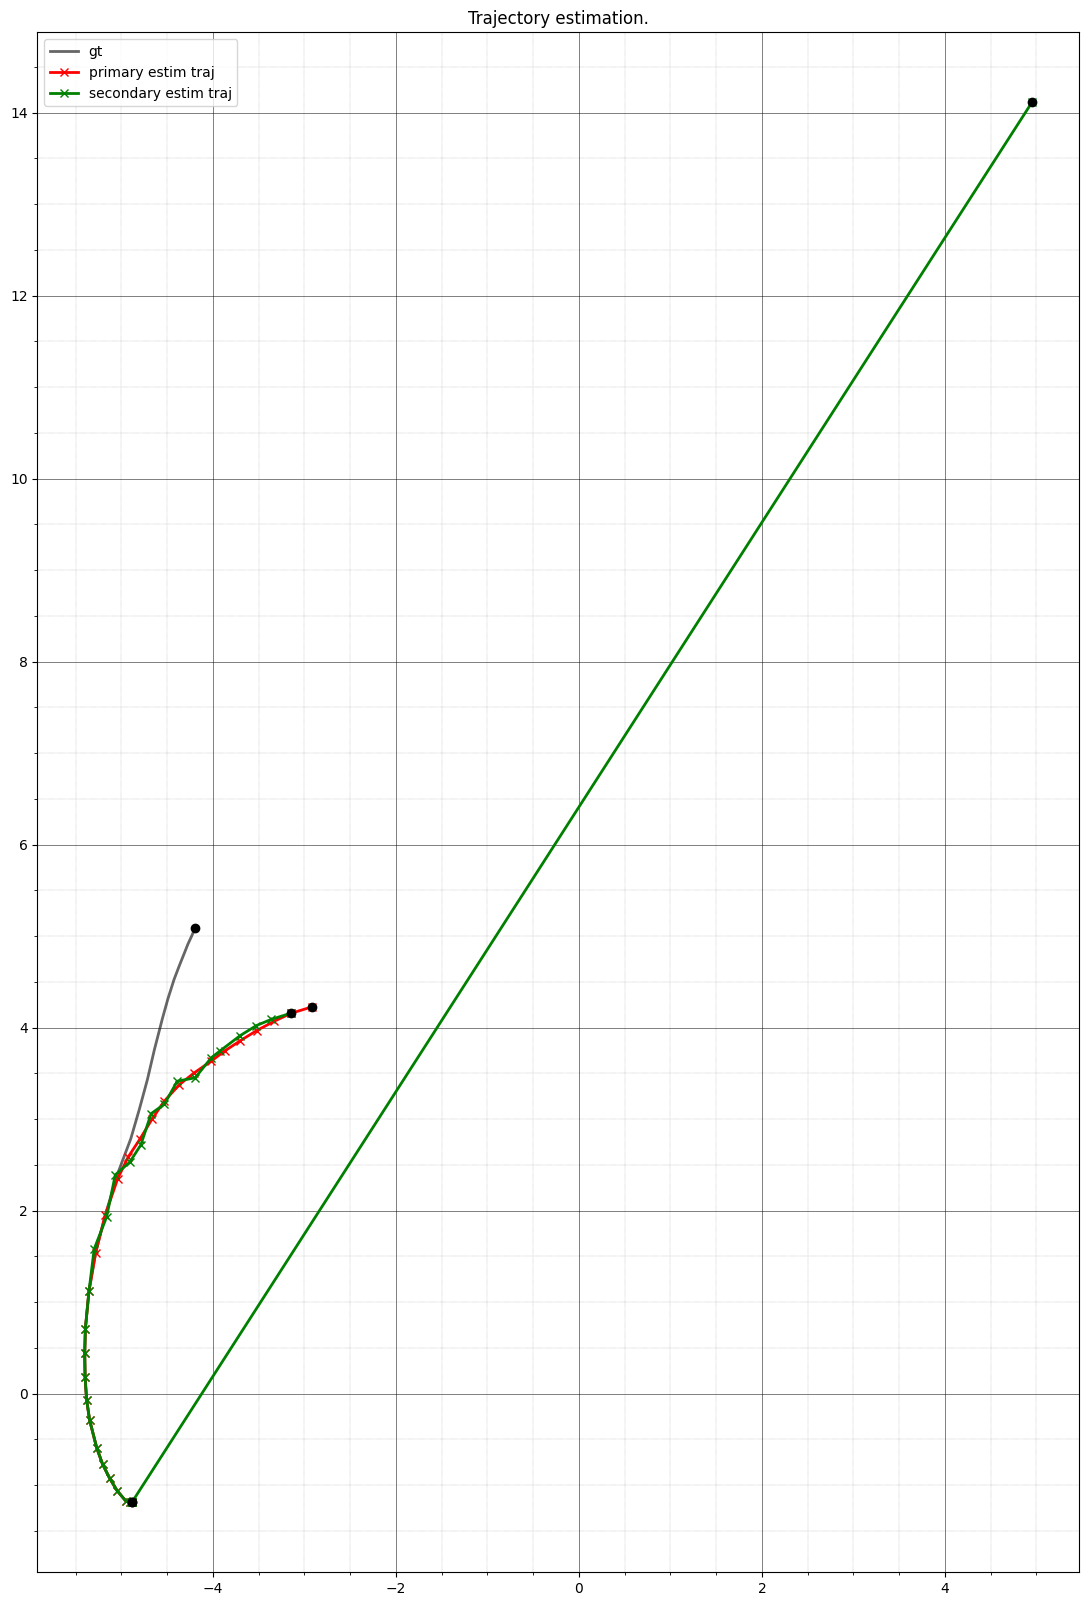

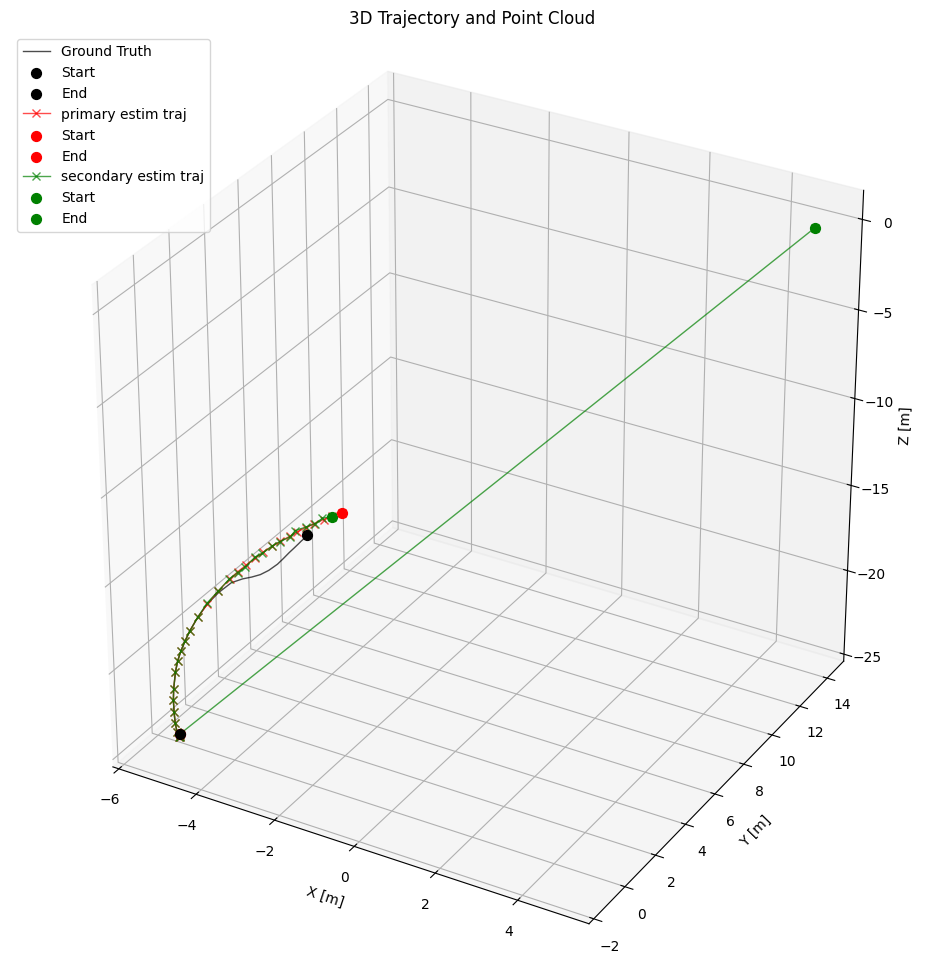

In [137]:
data_generator.generate_trajectory_map_2d(plane = 'xy', start = 0, end = 1, show = {'gt':True,'traj':True,'pts':False, 'align':False})

data_generator.generate_trajectory_map_3d(start = 0, end = 1, show = {'gt':True,'traj':True,'pts':False, 'align':False})


In [135]:
# from training.metrics import pose_err

# metrircs = {'ATE':pose_err}
# data_generator.print_metrics(metrircs)
     